# Week 7 — PCA on the NHANES Biomarkers

*INFO 521 worked notebook (Module 7). Companion to lecture m7a. Needs the course
environment (`info521` package).*

The other unsupervised question: not "which groups?" but "which **directions** matter?"
Center → covariance → eigendecomposition, from scratch, on all six standardized features.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from info521.data import load_clinical, hypertension

BLUE, VERMILLION, GREEN, ORANGE = "#0072B2", "#D55E00", "#009E73", "#E69F00"
rng = np.random.default_rng(521)

ds = load_clinical()
feat = ds["features"]                    # ['age','bmi','waist','chol','hdl','hba1c']
Fz = (ds["X"] - ds["X"].mean(0)) / ds["X"].std(0)    # center + standardize (units differ!)
N, D = Fz.shape

## Covariance → eigenvectors

In [2]:
C = (Fz.T @ Fz) / (N - 1)                # sample covariance of standardized features
vals, vecs = np.linalg.eigh(C)
vals, vecs = vals[::-1], vecs[:, ::-1]   # descending
# eigh's signs are arbitrary — fix a convention for readability
if vecs[feat.index("bmi"), 0] < 0: vecs[:, 0] = -vecs[:, 0]
if vecs[feat.index("age"), 1] < 0: vecs[:, 1] = -vecs[:, 1]
ve = vals / vals.sum()
print("variance explained:", ve.round(3))
print("cumulative        :", np.cumsum(ve).round(3))

variance explained: [0.373 0.218 0.172 0.125 0.097 0.013]
cumulative        : [0.373 0.591 0.764 0.889 0.987 1.   ]


## The scree plot

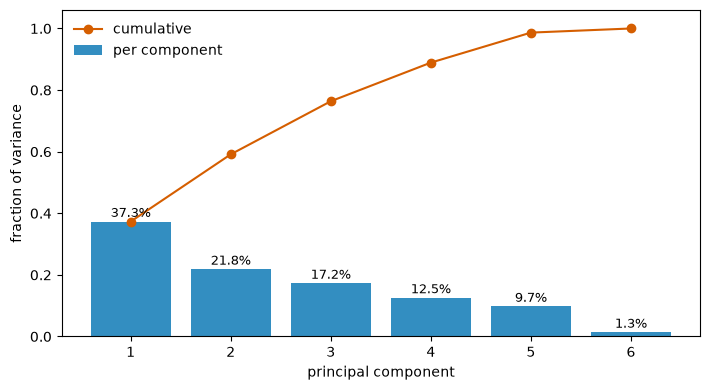

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4))
ks = np.arange(1, D + 1)
ax.bar(ks, ve, color=BLUE, alpha=0.8, label="per component")
ax.plot(ks, np.cumsum(ve), "o-", color=VERMILLION, label="cumulative")
for k in ks:
    ax.text(k, ve[k-1] + 0.015, f"{ve[k-1]*100:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("principal component"); ax.set_ylabel("fraction of variance")
ax.set_ylim(0, 1.06); ax.legend(frameon=False); plt.tight_layout(); plt.show()

PC1 carries 37.3%, PC1–2 59.1% — and PC6 a residual **1.3%**: the algebra's way of saying
one of these six numbers is nearly redundant. (We know which pair: BMI and waist,
$r \approx 0.90$.)

## What do the components mean?

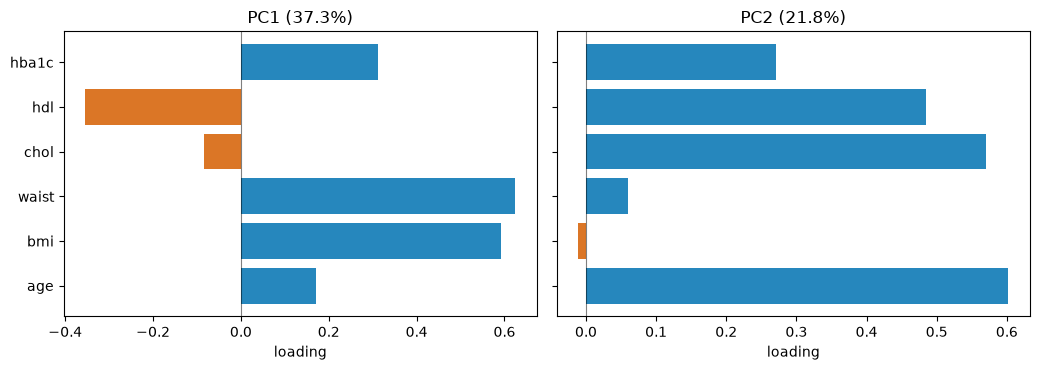

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
ypos = np.arange(D)
for i, ax in enumerate(axes):
    load = vecs[:, i]
    ax.barh(ypos, load, color=[VERMILLION if v < 0 else BLUE for v in load], alpha=0.85)
    ax.axvline(0, color="k", lw=0.8, alpha=0.5)
    ax.set_title(f"PC{i+1} ({ve[i]*100:.1f}%)"); ax.set_xlabel("loading")
axes[0].set_yticks(ypos); axes[0].set_yticklabels(feat)
plt.tight_layout(); plt.show()

PC1 is an **adiposity/metabolic axis** (BMI + waist + HbA1c, HDL opposing); PC2 an
**age–cholesterol axis**. Interpretability like this is a gift, not a guarantee.

## Patients in PC space — with the held-out label

Project the cohort onto (PC1, PC2) and *then* color by the hypertension label PCA never saw:

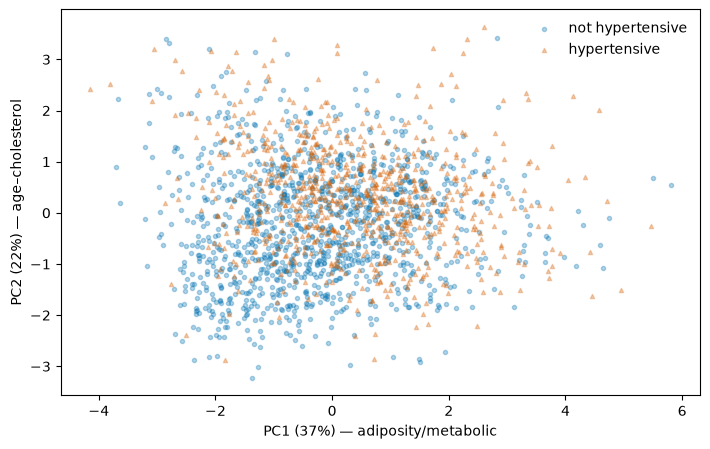

In [5]:
scores = Fz @ vecs
labels, _ = hypertension(ds)
show = rng.choice(N, 2000, replace=False)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
for val, col, mk, lab in [(0, BLUE, "o", "not hypertensive"), (1, VERMILLION, "^", "hypertensive")]:
    m = labels[show] == val
    ax.scatter(scores[show][m, 0], scores[show][m, 1], s=9, alpha=0.3,
               color=col, marker=mk, label=lab)
ax.set_xlabel(f"PC1 ({ve[0]*100:.0f}%) — adiposity/metabolic")
ax.set_ylabel(f"PC2 ({ve[1]*100:.0f}%) — age–cholesterol")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

The label *shifts* along both axes but the clouds overlap heavily — **variance explained ≠
usefulness for prediction**. A direction PCA ranks low can still carry the diagnostic
signal; PCA never saw the label and doesn't optimize for it.

**Try it yourself:** reconstruct the data from the top $K$ components
($\hat{\mathbf{X}} = \mathbf{Z}_K \mathbf{V}_K^\top$) and plot reconstruction error vs.
$K$. Confirm it equals the variance *not* explained — the two views of PCA are one.